In [14]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [15]:
import yfinance as yf
import pandas as pd

# Six companies to analyse (mix of tech + finance)
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "TSLA"]

# Download 3 years of daily data
data = yf.download(tickers, start="2022-01-01", end="2024-12-31", auto_adjust=True)

# Keep just the closing prices
prices = data["Close"]

prices.tail()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,TSLA
Date,,,,,,
2024-12-23,253.430847,225.059998,193.618713,230.179596,430.147217,430.600006
2024-12-24,256.339722,229.050003,195.090988,233.964600,434.179352,462.279999
2024-12-26,257.153809,227.050003,194.583664,234.765991,432.973694,454.130005
2024-12-27,253.748535,223.750000,191.758408,232.863861,425.482544,431.660004
2024-12-30,250.382950,221.300003,190.246323,231.077576,419.849335,417.410004


In [16]:
print("Shape:", prices.shape)      # (roughly 750 rows, 6 columns)
print("\nDate range:", prices.index.min().date(), "to", prices.index.max().date())
prices.describe().round(2)

Shape: (752, 6)

Date range: 2022-01-03 to 2024-12-30


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,TSLA
count,752.00,752.00,752.00,752.00,752.00,752.00
mean,175.62,144.02,131.34,148.86,326.94,236.86
std,29.33,35.13,27.14,37.76,70.74,60.91
min,122.83,81.82,82.70,93.37,207.73,108.10
25%,153.09,115.01,109.23,120.43,263.44,189.87
50%,170.87,140.19,130.31,135.65,318.06,233.13
75%,189.24,175.36,150.29,182.94,402.96,267.44
max,257.15,232.93,195.64,241.67,460.33,479.86


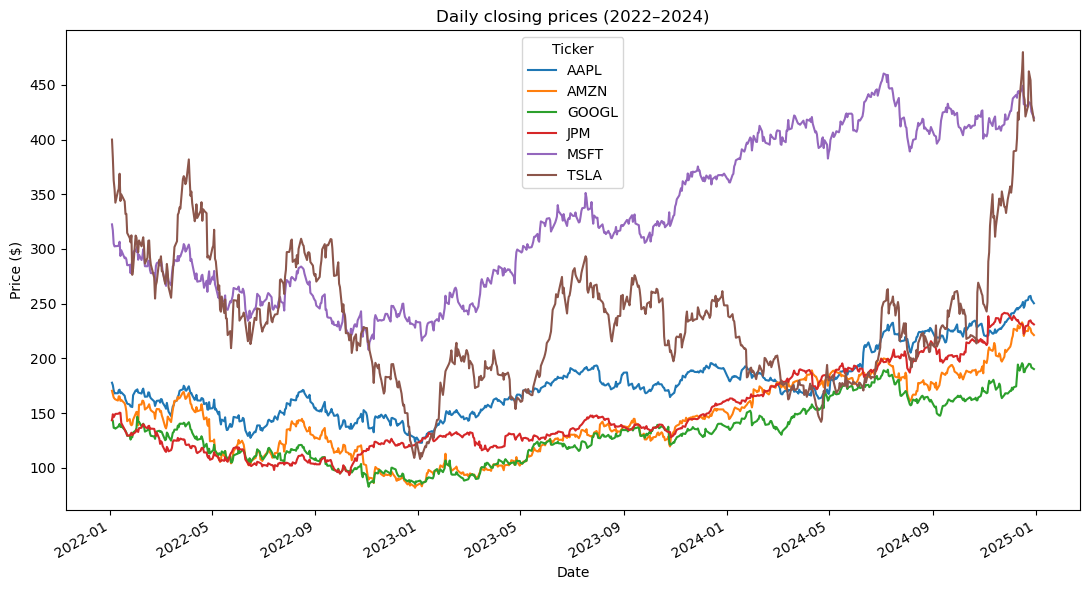

In [17]:
import matplotlib.pyplot as plt

prices.plot(figsize=(11, 6), title="Daily closing prices (2022–2024)")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("prices.png", dpi=150)
plt.show()

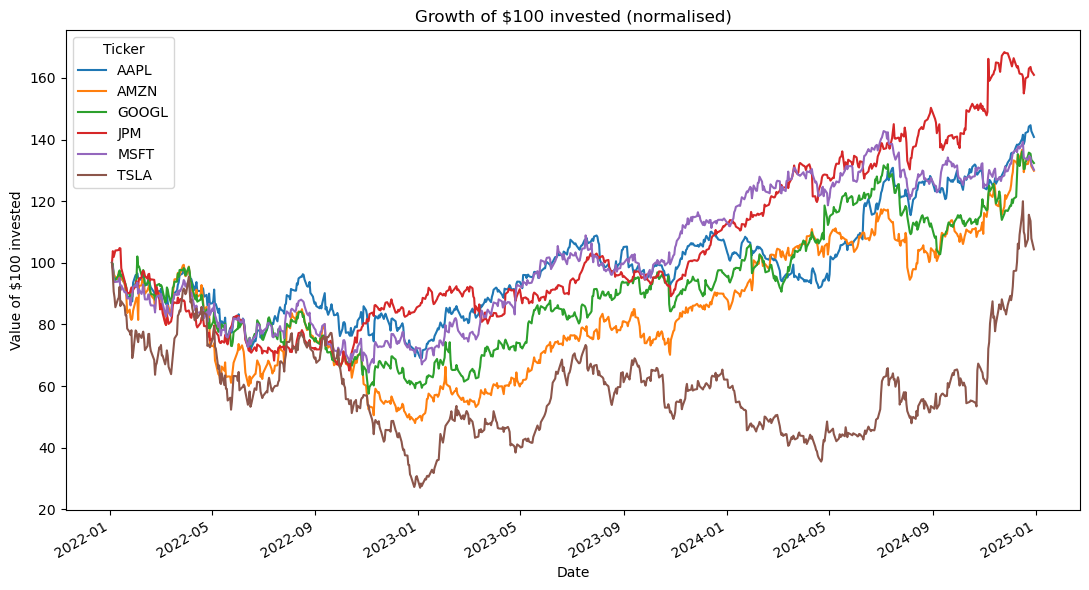

In [18]:
# Rebase every stock so it starts at 100
normalised = prices / prices.iloc[0] * 100

normalised.plot(figsize=(11, 6), title="Growth of $100 invested (normalised)")
plt.ylabel("Value of $100 invested")
plt.tight_layout()
plt.savefig("normalised_growth.png", dpi=150)
plt.show()

In [19]:
# Percentage change from each day to the next
returns = prices.pct_change().dropna()

returns.tail()

Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,TSLA
Date,,,,,,
2024-12-23,0.003065,0.000622,0.016823,0.003325,-0.003092,0.022657
2024-12-24,0.011478,0.017729,0.007604,0.016444,0.009374,0.073572
2024-12-26,0.003176,-0.008732,-0.002600,0.003425,-0.002777,-0.017630
2024-12-27,-0.013242,-0.014534,-0.014519,-0.008102,-0.017302,-0.049479
2024-12-30,-0.013263,-0.010950,-0.007885,-0.007671,-0.013240,-0.033012


In [20]:
# Average daily return, and a rough annual figure
print("Average daily return (%):")
print((returns.mean() * 100).round(3))

print("\nApproximate annual return (%):")
print((returns.mean() * 252 * 100).round(1))

Average daily return (%):
Ticker
AAPL     0.060
AMZN     0.064
GOOGL    0.059
JPM      0.076
MSFT     0.050
TSLA     0.080
dtype: float64

Approximate annual return (%):
Ticker
AAPL     15.2
AMZN     16.1
GOOGL    14.8
JPM      19.1
MSFT     12.7
TSLA     20.1
dtype: float64


In [21]:
print("Best single day per stock (%):")
print((returns.max() * 100).round(2))

print("\nWorst single day per stock (%):")
print((returns.min() * 100).round(2))

Best single day per stock (%):
Ticker
AAPL      8.90
AMZN     13.54
GOOGL    10.22
JPM      11.54
MSFT      8.23
TSLA     21.92
dtype: float64

Worst single day per stock (%):
Ticker
AAPL     -5.87
AMZN    -14.05
GOOGL    -9.51
JPM      -6.47
MSFT     -7.72
TSLA    -12.33
dtype: float64


In [22]:
import numpy as np

# Annualised volatility (%) — higher = riskier
ann_vol = returns.std() * np.sqrt(252) * 100

print("Annualised volatility (%):")
print(ann_vol.round(1).sort_values(ascending=False))

Annualised volatility (%):
Ticker
TSLA     61.3
AMZN     38.4
GOOGL    32.8
MSFT     27.6
AAPL     27.1
JPM      25.0
dtype: float64


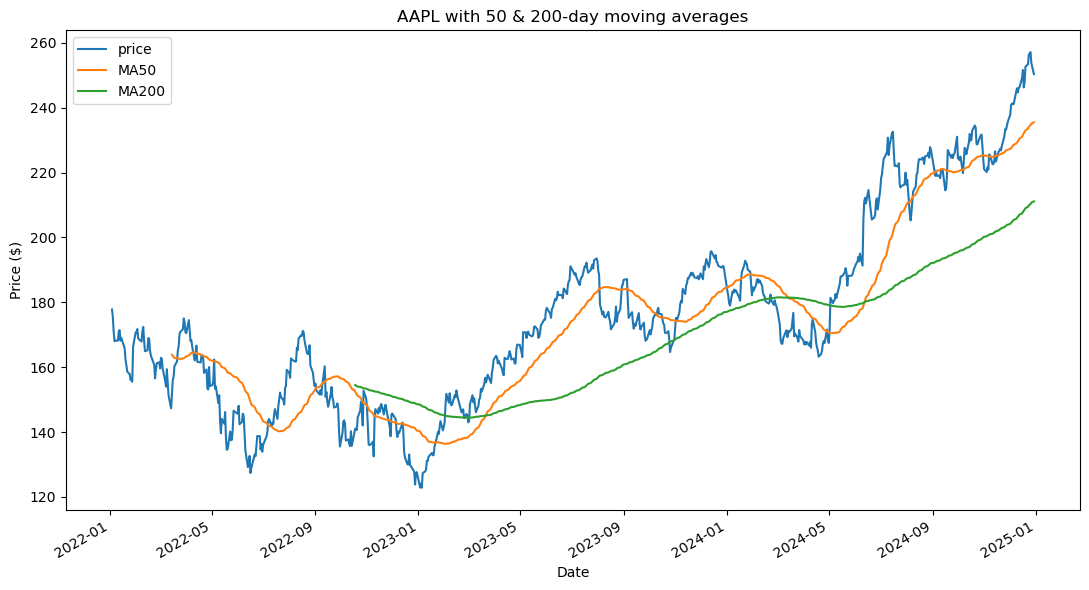

In [23]:
import matplotlib.pyplot as plt

# Take one stock and add its moving averages
stock = prices["AAPL"].to_frame("price")
stock["MA50"] = stock["price"].rolling(50).mean()
stock["MA200"] = stock["price"].rolling(200).mean()

stock.plot(figsize=(11, 6), title="AAPL with 50 & 200-day moving averages")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("moving_averages.png", dpi=150)
plt.show()

In [24]:
corr = returns.corr()
corr.round(2)

Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,TSLA
Ticker,,,,,,
AAPL,1.00,0.56,0.62,0.35,0.68,0.50
AMZN,0.56,1.00,0.65,0.35,0.69,0.45
GOOGL,0.62,0.65,1.00,0.32,0.69,0.40
JPM,0.35,0.35,0.32,1.00,0.33,0.30
MSFT,0.68,0.69,0.69,0.33,1.00,0.42
TSLA,0.50,0.45,0.40,0.30,0.42,1.00


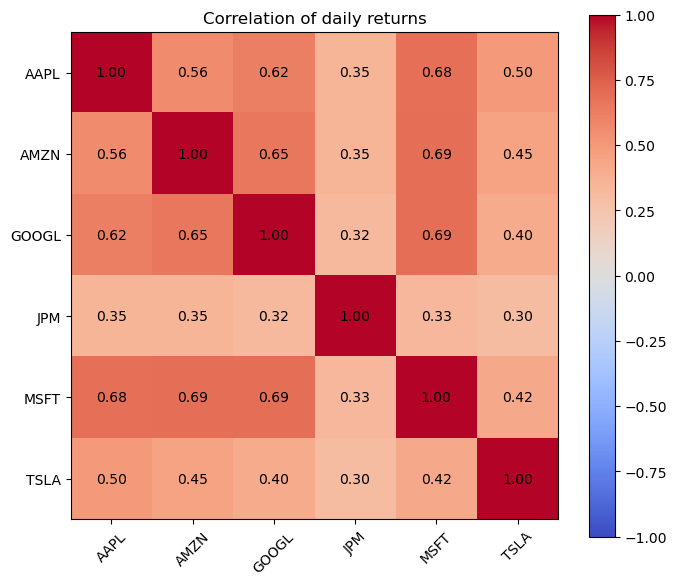

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im); plt.title("Correlation of daily returns")
plt.tight_layout(); plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [27]:
# Reshape into a tidy long table for Power BI
long   = prices.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Close")
retl   = returns.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="DailyReturn")
tidy   = long.merge(retl, on=["Date", "Ticker"])
tidy["MA50"] = tidy.groupby("Ticker")["Close"].transform(lambda s: s.rolling(50).mean())
tidy = tidy.sort_values(["Ticker", "Date"])

tidy.to_csv("data/market_data_for_powerbi.csv", index=False)
print("Saved:", tidy.shape[0], "rows")
tidy.head()

Saved: 4506 rows


,Date,Ticker,Close,DailyReturn,MA50
0,2022-01-04,AAPL,175.530014,-0.012692,NaN
1,2022-01-05,AAPL,170.860931,-0.026600,NaN
2,2022-01-06,AAPL,168.008698,-0.016693,NaN
3,2022-01-07,AAPL,168.174744,0.000988,NaN
4,2022-01-10,AAPL,168.194290,0.000116,NaN
